# Decision Trees

In [224]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score,classification_report,confusion_matrix
from sklearn.tree import plot_tree

In [225]:
titanic=sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [226]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [227]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [228]:
features=["pclass","sex","fare","embarked","age"]
target=["survived"]

In [229]:
# Missing data
from sklearn.impute import SimpleImputer

imp_mean=SimpleImputer(strategy="mean")
titanic[["age"]]= imp_mean.fit_transform(titanic[["age"]])
imp_freq=SimpleImputer(strategy="most_frequent")
titanic[["embarked"]]=imp_freq.fit_transform(titanic[["embarked"]])

In [230]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [231]:
# Encoding
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
titanic["sex"]=le.fit_transform(titanic["sex"])
titanic["embarked"]=le.fit_transform(titanic["embarked"])

In [232]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True


In [233]:
X=titanic[features]
y=titanic[target]

In [234]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

## Decision Tree model

In [235]:
from sklearn.tree import DecisionTreeClassifier

model=DecisionTreeClassifier()
model.fit(X_train,y_train)

DecisionTreeClassifier()

In [236]:
y_pred=model.predict(X_test)
y_pred

array([0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 1, 1])

In [237]:
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score,classification_report,confusion_matrix
print("accuracy_score",accuracy_score(y_test,y_pred))

accuracy_score 0.776536312849162


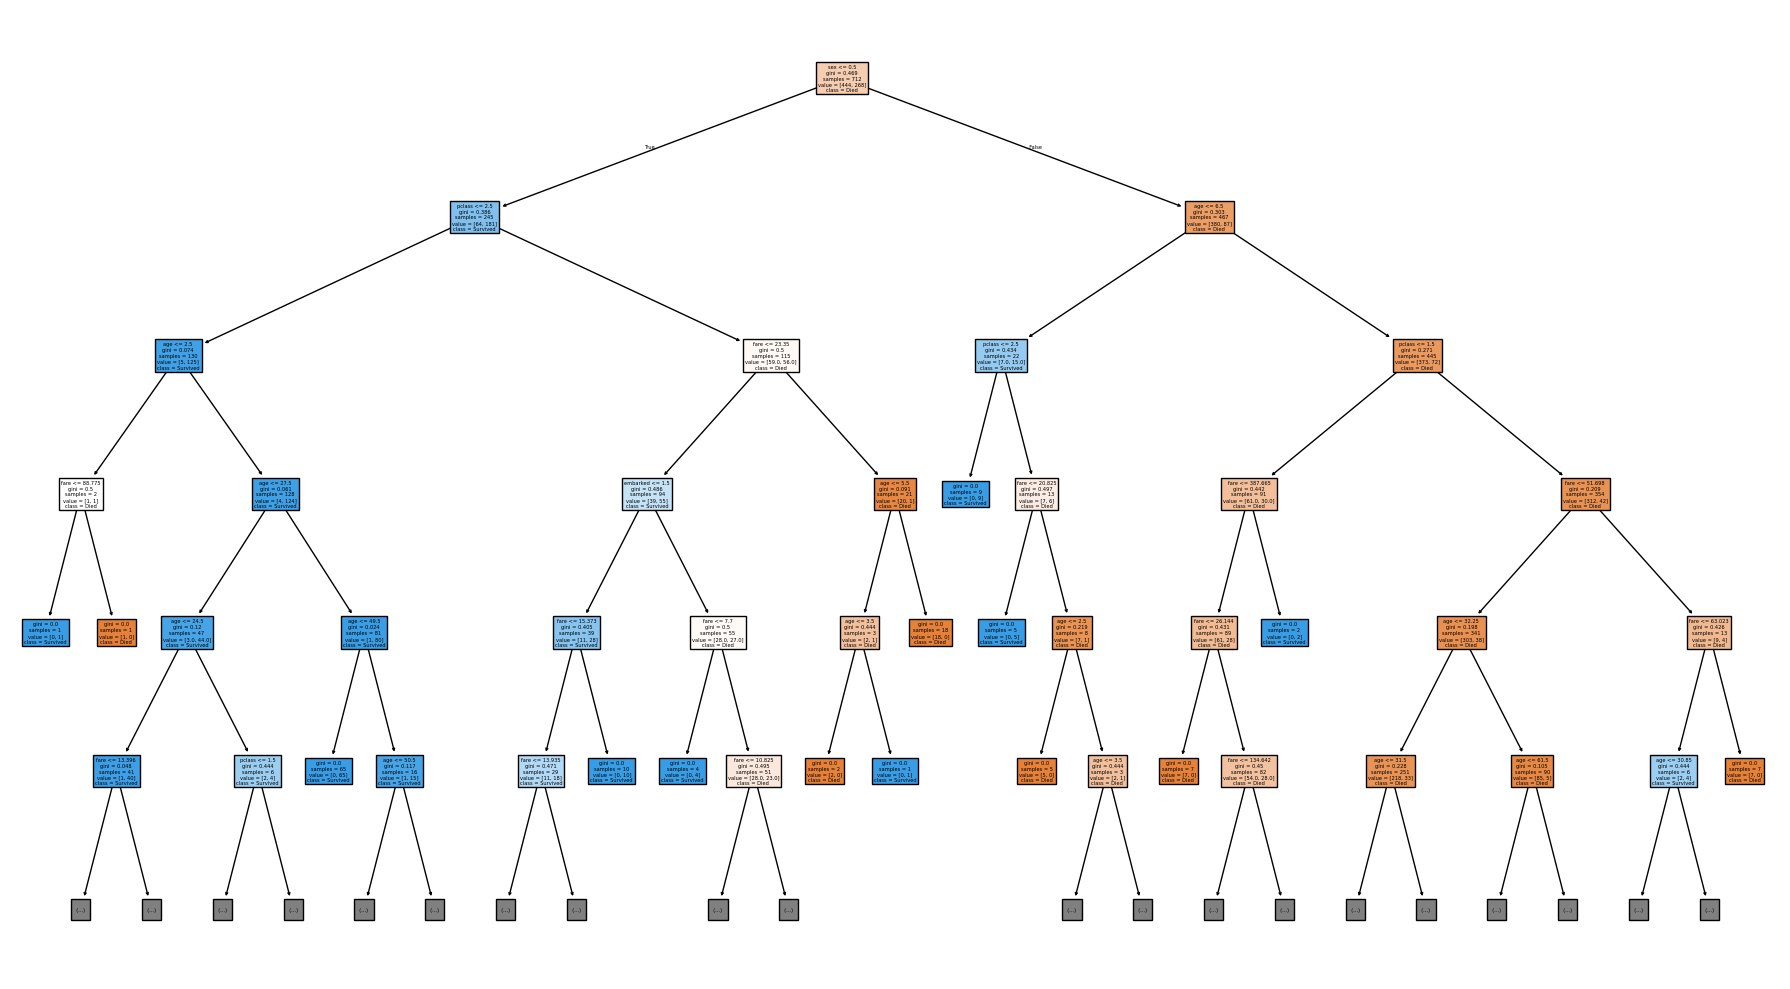

In [238]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died","Survived"],
    filled=True,
    max_depth=5
)
plt.tight_layout()
plt.show()

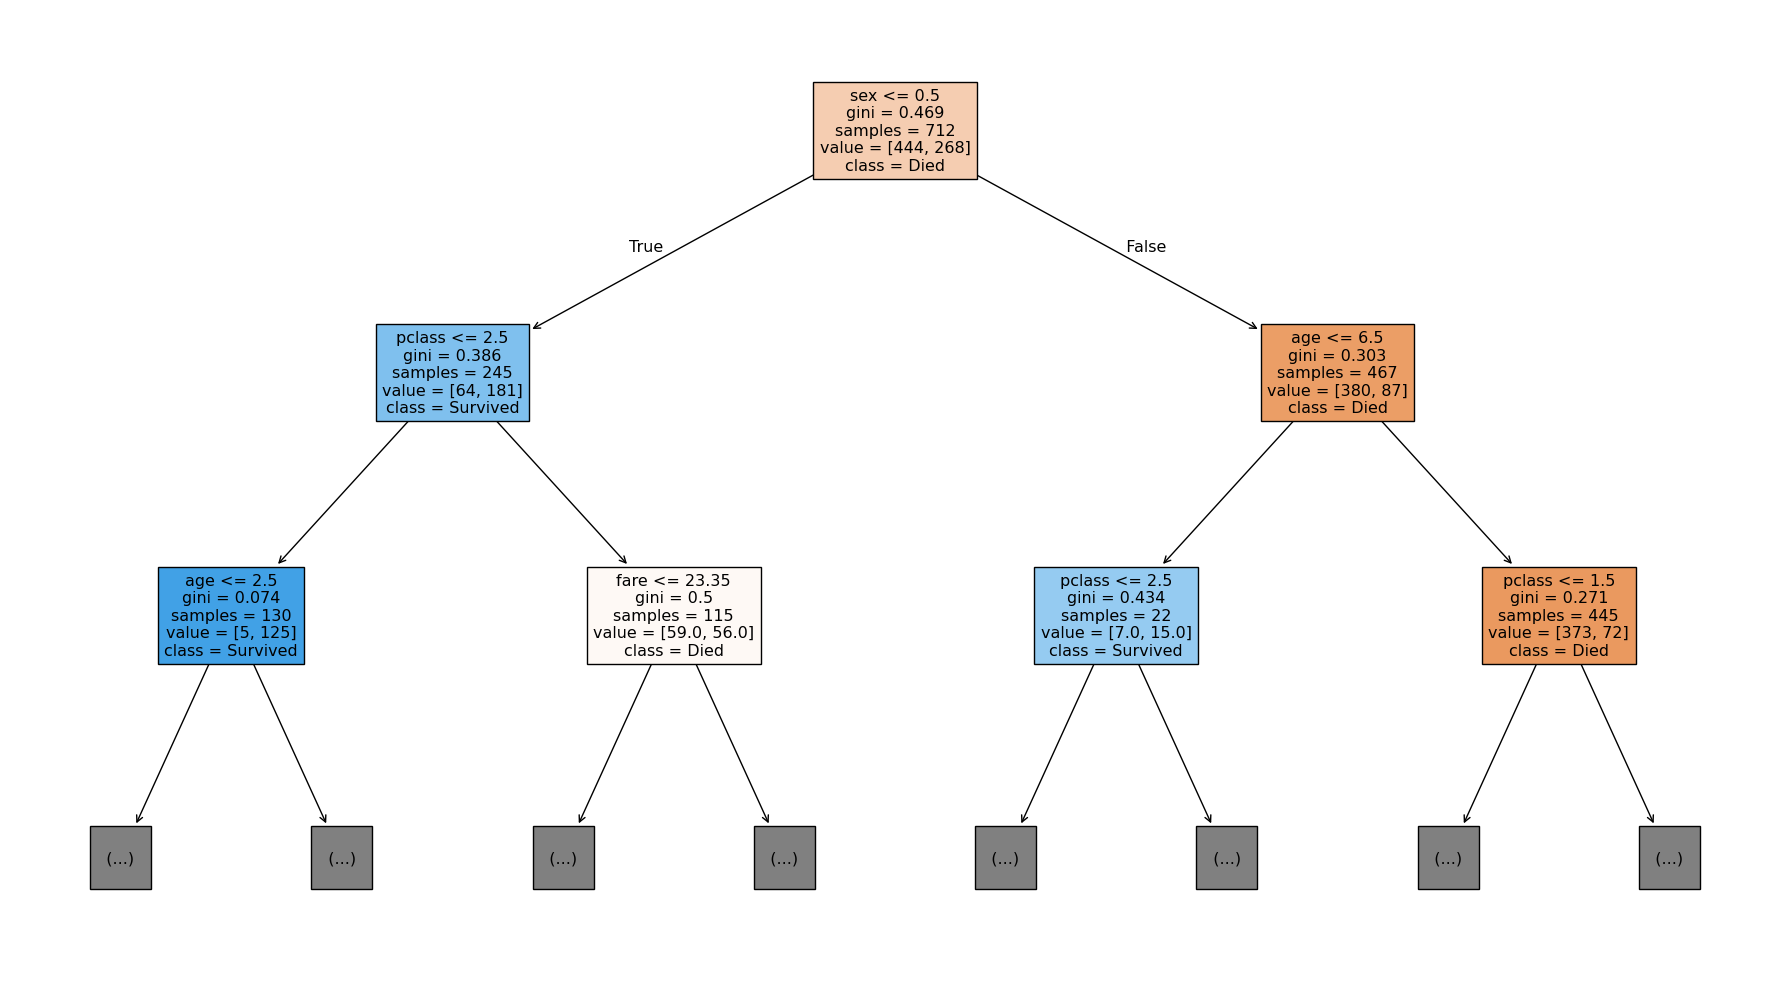

In [239]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died","Survived"],
    filled=True,
    max_depth=2
)
plt.tight_layout()
plt.show()

## Decision Tree with Pre-Pruning

In [240]:
max_depth=[2,3,4,5,6,7,8,9,10]

for depth in max_depth:
    model =DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train,y_train)

    acc=model.score(X_test,y_test)
    print(f"For Depth={depth}, Acc",acc)

For Depth=2, Acc 0.7653631284916201
For Depth=3, Acc 0.7988826815642458
For Depth=4, Acc 0.7988826815642458
For Depth=5, Acc 0.7988826815642458
For Depth=6, Acc 0.8044692737430168
For Depth=7, Acc 0.7988826815642458
For Depth=8, Acc 0.7821229050279329
For Depth=9, Acc 0.8044692737430168
For Depth=10, Acc 0.8044692737430168


In [241]:
min_samples_split=[10,15,20,25,30]

for split in min_samples_split:
    model =DecisionTreeClassifier(max_depth=7,min_samples_split=split)
    model.fit(X_train,y_train)

    acc=model.score(X_test,y_test)
    print(f"For min_samples_split={split}, Acc",acc)

For min_samples_split=10, Acc 0.8324022346368715
For min_samples_split=15, Acc 0.8268156424581006
For min_samples_split=20, Acc 0.8268156424581006
For min_samples_split=25, Acc 0.8100558659217877
For min_samples_split=30, Acc 0.7988826815642458


## Decision Tree with Pre-Pruning

In [242]:
full_tree=DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train,y_train)


DecisionTreeClassifier(random_state=42)

In [243]:
path=full_tree.cost_complexity_pruning_path(X_train,y_train)
ccp_alphas=path.ccp_alphas
print(ccp_alphas)

[0.00000000e+00 0.00000000e+00 3.12109863e-05 6.68806849e-05
 8.91742465e-05 1.63857678e-04 2.00642055e-04 2.34082397e-04
 2.34082397e-04 3.51123596e-04 4.68164794e-04 4.68164794e-04
 4.68164794e-04 4.68164794e-04 5.35045479e-04 5.61797753e-04
 6.24219725e-04 6.24219725e-04 6.67991230e-04 7.02247191e-04
 8.19288390e-04 8.19288390e-04 8.42696629e-04 8.42696629e-04
 8.42696629e-04 8.94231048e-04 9.24769963e-04 9.36329588e-04
 9.36329588e-04 9.36329588e-04 1.01064146e-03 1.05337079e-03
 1.07400895e-03 1.07953294e-03 1.08038029e-03 1.11865144e-03
 1.12359551e-03 1.12359551e-03 1.13139825e-03 1.17041199e-03
 1.18841832e-03 1.22566125e-03 1.22893258e-03 1.22893258e-03
 1.24843945e-03 1.27565833e-03 1.30996111e-03 1.33761370e-03
 1.37044603e-03 1.51229549e-03 1.56737310e-03 1.60434338e-03
 1.64211936e-03 1.66892062e-03 1.75561798e-03 1.76144762e-03
 1.86751451e-03 2.10674157e-03 2.41226470e-03 2.64273538e-03
 2.69412911e-03 3.43770913e-03 3.56327570e-03 5.47433606e-03
 9.05540038e-03 1.392950

In [244]:
# Train our model for all alphas

trees=[]
for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42)
    model.fit(X_train,y_train)
    acc=model.score(X_test,y_test)

    trees.append((model,alpha))

print(trees)
     


[(DecisionTreeClassifier(random_state=42), np.float64(0.0)), (DecisionTreeClassifier(random_state=42), np.float64(0.0)), (DecisionTreeClassifier(random_state=42), np.float64(3.1210986267166726e-05)), (DecisionTreeClassifier(random_state=42), np.float64(6.688068485821317e-05)), (DecisionTreeClassifier(random_state=42), np.float64(8.917424647761699e-05)), (DecisionTreeClassifier(random_state=42), np.float64(0.00016385767790262282)), (DecisionTreeClassifier(random_state=42), np.float64(0.00020064205457463822)), (DecisionTreeClassifier(random_state=42), np.float64(0.00023408239700374524)), (DecisionTreeClassifier(random_state=42), np.float64(0.00023408239700374546)), (DecisionTreeClassifier(random_state=42), np.float64(0.00035112359550561797)), (DecisionTreeClassifier(random_state=42), np.float64(0.0004681647940074905)), (DecisionTreeClassifier(random_state=42), np.float64(0.0004681647940074905)), (DecisionTreeClassifier(random_state=42), np.float64(0.0004681647940074905)), (DecisionTreeCl

In [245]:
best_acc=0
best_alpha=0

for model,alpha in trees:
    curr_acc=model.score(X_test,y_test)
    if curr_acc>best_acc:
        best_acc=curr_acc
        best_alpha=alpha



In [246]:
best_alpha

np.float64(0.0)

In [247]:
best_acc

0.7653631284916201

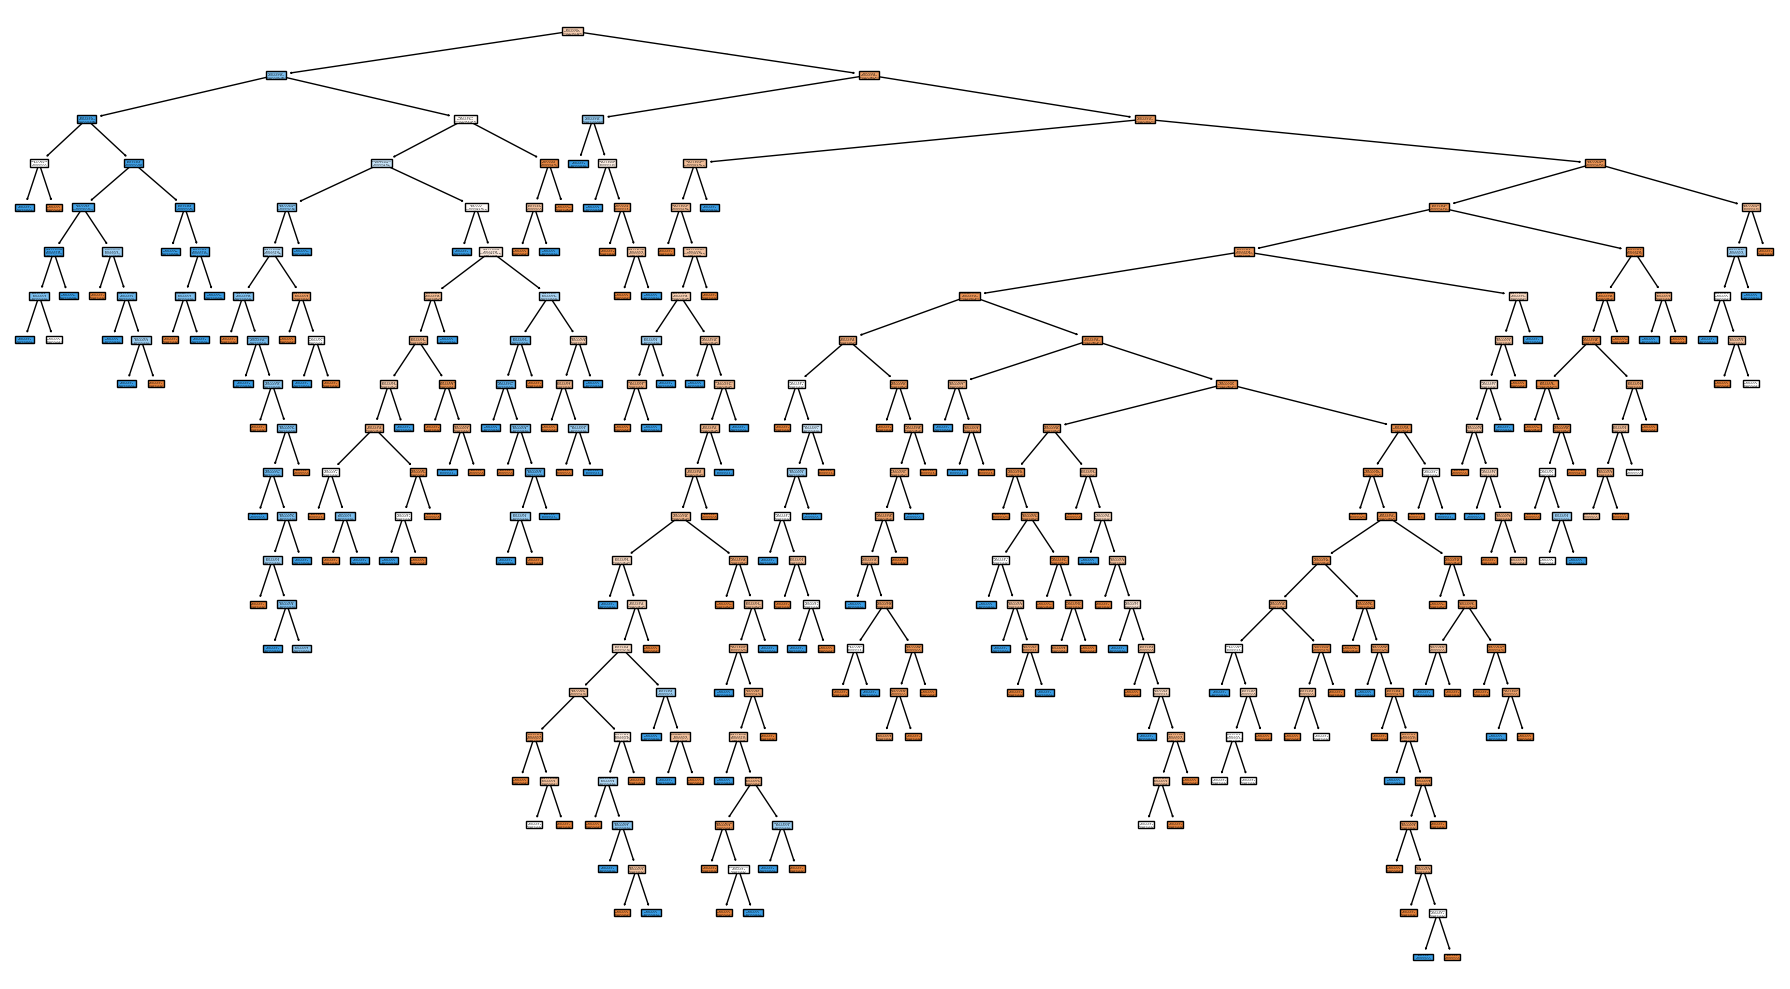

In [250]:
best_model=DecisionTreeClassifier(ccp_alpha=best_alpha)
best_model.fit(X_train,y_train)
plt.figure(figsize=(18,10))
plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=["Died","Survived"],
    filled=True
)
plt.tight_layout()
plt.show()


In [251]:
print(best_model.score(X_test,y_test))

0.7653631284916201
